# Generated vs. Real Dataset Quality Overview

This notebook visualizes the high-level quality metrics computed by `dataset_quality_checks.py`, comparing the LLM-generated datasets (per domain/model/shot/run) against the real datasets in multiple metrics.


## Imports 

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from dataset_quality_checks import *
from color_palette import *

# WARNINGS
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pkg_resources")

In [2]:
FONT_CONFIG = {
    'axes_title_size': 23,
    'axes_label_size': 20,
    'legend_size': 17,
    'tick_size': 20,
    'figure_title_size': 30,
    'axes_title_pad': 18,
}

In [3]:
PROJECT_ROOT = find_project_root()
QUALITY_DIR = PROJECT_ROOT / "analysis" / "quality_checks"
FIGURES_DIR = PROJECT_ROOT / "figures"

In [4]:
summary_by_run_path = QUALITY_DIR / "summary_by_run.csv"
summary_by_domain_model_shot_path = QUALITY_DIR / "summary_by_domain_model_shot.csv"
real_metrics_path = QUALITY_DIR / "real_dataset_metrics.csv"

summary_by_run = pd.read_csv(summary_by_run_path)
summary_by_domain_model_shot = pd.read_csv(summary_by_domain_model_shot_path)
real_metrics = pd.read_csv(real_metrics_path)

print(summary_by_run.shape, summary_by_domain_model_shot.shape, real_metrics.shape)
summary_by_run

(81, 34) (27, 116) (3, 8)


,domain,model,shot,generated_path,run_id,run_name,generated_row_count,generated_column_count,generated_overall_missing_pct,generated_duplicate_rows,...,categorical_avg_js_divergence_real_vs_generated,text_avg_length_real_mean,text_avg_length_generated_mean,text_avg_length_abs_diff_mean,text_empty_pct_generated_mean,numeric_outlier_pct_mean,categorical_unexpected_value_pct_mean,date_invalid_values_pct_mean,row_constraints_mean_violations_pct,row_constraints_max_violations_pct
0,hatecrime,kimi-k2-instruct-0905,few,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1004,20,7.250996,3,...,0.300734,10.0,10.000000,0.000000,0.0,0.661396,5.296994,0.000000,4.880478,9.760956
1,hatecrime,kimi-k2-instruct-0905,one,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1000,20,1.350000,2,...,0.432172,10.0,10.000000,0.000000,0.0,1.430578,28.333479,0.000000,0.000000,0.000000
2,hatecrime,kimi-k2-instruct-0905,zero,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1042,20,0.460653,6,...,0.588815,10.0,10.000000,0.000000,0.0,1.523512,50.112676,0.000000,0.047985,0.095969
3,hatecrime,kimi-k2-instruct-0905,few,data/generated/kimi-k2-instruct-0905-run2/hate...,run2,kimi-k2-instruct-0905-run2,1007,20,9.289970,7,...,0.290297,10.0,10.000000,0.000000,0.0,0.527931,5.100659,0.000000,0.893744,1.787488
4,hatecrime,kimi-k2-instruct-0905,one,data/generated/kimi-k2-instruct-0905-run2/hate...,run2,kimi-k2-instruct-0905-run2,998,20,0.931864,2,...,0.449221,10.0,10.009018,0.009018,0.0,0.984710,31.111929,0.301508,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,lending,qwen3-coder-30b-a3b-instruct,one,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run2,qwen3-coder-30b-a3b-instruct-run2,461,58,11.848306,12,...,0.523393,2.0,2.054348,0.054348,0.0,8.355103,43.208233,NaN,90.889371,90.889371
77,lending,qwen3-coder-30b-a3b-instruct,zero,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run2,qwen3-coder-30b-a3b-instruct-run2,703,58,5.245990,43,...,0.705450,2.0,1.950213,0.049787,0.0,5.854462,72.746951,NaN,3.413940,3.413940
78,lending,qwen3-coder-30b-a3b-instruct,few,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run3,qwen3-coder-30b-a3b-instruct-run3,629,58,16.989200,90,...,0.396162,2.0,2.028617,0.028617,0.0,7.079288,26.275928,NaN,33.545310,33.545310
79,lending,qwen3-coder-30b-a3b-instruct,one,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run3,qwen3-coder-30b-a3b-instruct-run3,505,58,11.812905,17,...,0.533684,2.0,2.013944,0.013944,0.0,7.457681,44.594165,NaN,93.465347,93.465347


In [5]:
merged_runs = summary_by_run.merge(real_metrics, on="domain", suffixes=("", "_real_only"))

value_cols = [
    "generated_duplicate_rows_pct",
    "real_duplicate_rows_pct",
    "generated_overall_missing_pct",
    "real_overall_missing_pct",
]

merged_runs["duplicate_pct_delta"] = (
    merged_runs["generated_duplicate_rows_pct"] - merged_runs["real_duplicate_rows_pct"]
)
merged_runs["missing_pct_delta"] = (
    merged_runs["generated_overall_missing_pct"] - merged_runs["real_overall_missing_pct"]
)

merged_runs

,domain,model,shot,generated_path,run_id,run_name,generated_row_count,generated_column_count,generated_overall_missing_pct,generated_duplicate_rows,...,row_constraints_max_violations_pct,row_count,column_count,overall_missing_pct,duplicate_rows,duplicate_rows_pct,duplicate_rows_primary_key,duplicate_rows_primary_key_pct,duplicate_pct_delta,missing_pct_delta
0,hatecrime,kimi-k2-instruct-0905,few,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1004,20,7.250996,3,...,9.760956,265834,20,13.516142,4084,1.536297,16901,6.357727,-1.237492,-6.265146
1,hatecrime,kimi-k2-instruct-0905,one,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1000,20,1.350000,2,...,0.000000,265834,20,13.516142,4084,1.536297,16901,6.357727,-1.336297,-12.166142
2,hatecrime,kimi-k2-instruct-0905,zero,data/generated/kimi-k2-instruct-0905-run1/hate...,run1,kimi-k2-instruct-0905-run1,1042,20,0.460653,6,...,0.095969,265834,20,13.516142,4084,1.536297,16901,6.357727,-0.960481,-13.055489
3,hatecrime,kimi-k2-instruct-0905,few,data/generated/kimi-k2-instruct-0905-run2/hate...,run2,kimi-k2-instruct-0905-run2,1007,20,9.289970,7,...,1.787488,265834,20,13.516142,4084,1.536297,16901,6.357727,-0.841163,-4.226171
4,hatecrime,kimi-k2-instruct-0905,one,data/generated/kimi-k2-instruct-0905-run2/hate...,run2,kimi-k2-instruct-0905-run2,998,20,0.931864,2,...,0.000000,265834,20,13.516142,4084,1.536297,16901,6.357727,-1.335896,-12.584278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,lending,qwen3-coder-30b-a3b-instruct,one,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run2,qwen3-coder-30b-a3b-instruct-run2,461,58,11.848306,12,...,90.889371,12229298,58,16.233921,32748,0.267783,5006136,40.935596,2.335254,-4.385615
77,lending,qwen3-coder-30b-a3b-instruct,zero,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run2,qwen3-coder-30b-a3b-instruct-run2,703,58,5.245990,43,...,3.413940,12229298,58,16.233921,32748,0.267783,5006136,40.935596,5.848860,-10.987930
78,lending,qwen3-coder-30b-a3b-instruct,few,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run3,qwen3-coder-30b-a3b-instruct-run3,629,58,16.989200,90,...,33.545310,12229298,58,16.233921,32748,0.267783,5006136,40.935596,14.040643,0.755280
79,lending,qwen3-coder-30b-a3b-instruct,one,data/generated/qwen3-coder-30b-a3b-instruct-ru...,run3,qwen3-coder-30b-a3b-instruct-run3,505,58,11.812905,17,...,93.465347,12229298,58,16.233921,32748,0.267783,5006136,40.935596,3.098553,-4.421015


## Duplicate Rows

In [6]:
dup_summary = (
    merged_runs
    .groupby(["domain", "model", "shot"], as_index=False)
    .agg({
        "generated_duplicate_rows_pct": "mean",
        "real_duplicate_rows_pct": "mean",
        "duplicate_pct_delta": "mean",
    })
    .sort_values(["domain", "model", "shot"])
)

dup_summary

,domain,model,shot,generated_duplicate_rows_pct,real_duplicate_rows_pct,duplicate_pct_delta
0,employment,kimi-k2-instruct-0905,few,0.000000,0.000000,0.000000
1,employment,kimi-k2-instruct-0905,one,0.000000,0.000000,0.000000
2,employment,kimi-k2-instruct-0905,zero,0.000000,0.000000,0.000000
3,employment,llama-3.1-8b-instruct,few,1.736505,0.000000,1.736505
4,employment,llama-3.1-8b-instruct,one,4.726465,0.000000,4.726465
5,employment,llama-3.1-8b-instruct,zero,0.417753,0.000000,0.417753
6,employment,qwen3-coder-30b-a3b-instruct,few,0.476485,0.000000,0.476485
7,employment,qwen3-coder-30b-a3b-instruct,one,0.647072,0.000000,0.647072
8,employment,qwen3-coder-30b-a3b-instruct,zero,0.000000,0.000000,0.000000
9,hatecrime,kimi-k2-instruct-0905,few,0.463065,1.536297,-1.073232


In [7]:
models = ordered_levels(dup_summary["model"].unique(), MODEL_ORDER)
domains = ordered_levels(dup_summary["domain"].unique(), DOMAIN_ORDER)
shots = sorted(dup_summary["shot"].unique())

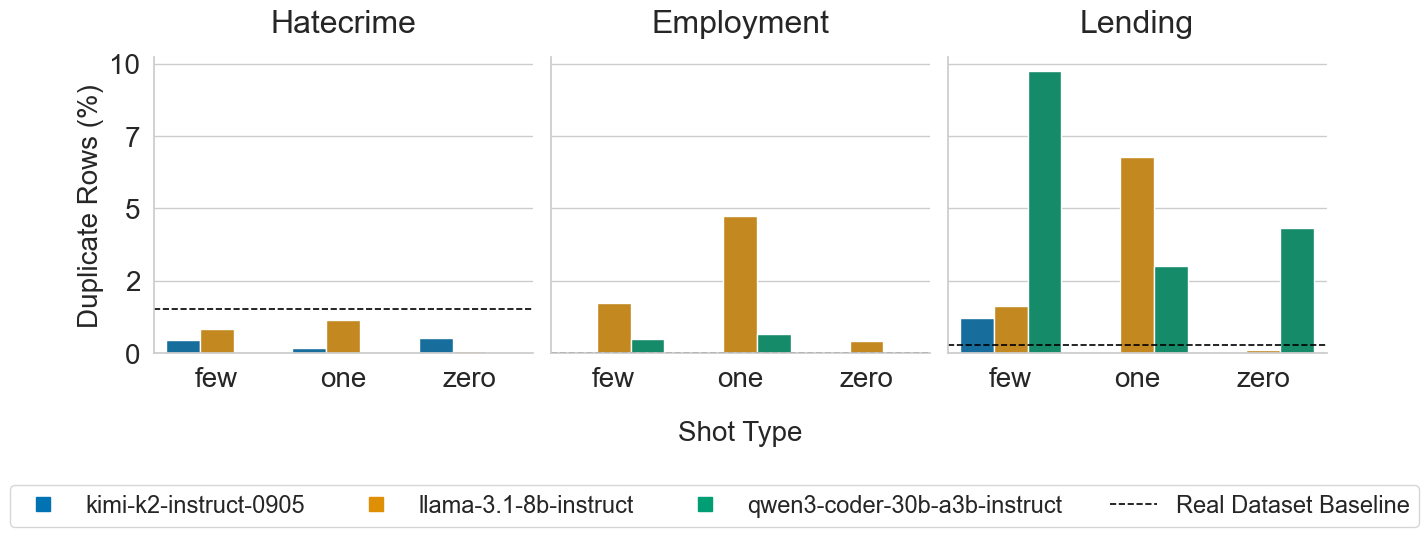

In [8]:
g_dom = sns.catplot(
    data=dup_summary,
    kind="bar",
    x="shot",
    y="generated_duplicate_rows_pct",
    hue="model",
    col="domain",
    hue_order=models,
    col_order=domains,
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.05,
    sharey=True,
    legend=False,
)

g_dom.fig.set_size_inches(4 * 1.05 * len(domains), 4)

g_dom.set_titles("{col_name}")

for i, (ax, domain) in enumerate(zip(g_dom.axes.flat, domains)):
    # Add baseline line
    baseline = real_metrics.loc[real_metrics["domain"] == domain, "duplicate_rows_pct"]
    if not baseline.empty:
        ax.axhline(
            y=baseline.iloc[0],
            color="black",
            linestyle="--",
            linewidth=1.2,
        )
    
    ax.set_title(
        domain.capitalize(),
        fontsize=FONT_CONFIG['axes_title_size'],
        pad=FONT_CONFIG['axes_title_pad'],
    )
    if i == len(domains) // 2:
        ax.set_xlabel("Shot Type", fontsize=FONT_CONFIG['axes_label_size'], labelpad=20)
    else:
        ax.set_xlabel("", fontsize=FONT_CONFIG['axes_label_size'])
    ax.set_ylabel("Duplicate Rows (%)", fontsize=FONT_CONFIG['axes_label_size'])
    ax.tick_params(axis='both', labelsize=FONT_CONFIG['tick_size'])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

handles_dom = [
    Line2D([0], [0], marker="s", linestyle="none", markersize=10, color=MODEL_PALETTE[model], label=model)
    for model in models
]

baseline_handle = Line2D(
    [0], [0], color="black", linestyle="--", linewidth=1.2, label="Real Dataset Baseline"
)
handles_dom.append(baseline_handle)
labels_dom = list(models) + ["Real Dataset Baseline"]

g_dom.fig.legend(
    handles_dom,
    labels_dom,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=max(1, len(models) + 1),
    fontsize=FONT_CONFIG['legend_size'],
    frameon=True,
)

plt.savefig(FIGURES_DIR / "duplicate_rows_by_domain_shot_llm.png", bbox_inches='tight')
plt.show()

## Missing values

In [9]:
missing_summary = (
    summary_by_domain_model_shot[
        [
            "domain",
            "model",
            "shot",
            "generated_overall_missing_pct_mean",
            "real_overall_missing_pct_mean",
        ]
    ]
    .rename(
        columns={
            "generated_overall_missing_pct_mean": "generated_overall_missing_pct",
            "real_overall_missing_pct_mean": "real_overall_missing_pct",
        }
    )
)
missing_summary["missing_pct_delta"] = (
    missing_summary["generated_overall_missing_pct"] - missing_summary["real_overall_missing_pct"]
)
missing_summary = missing_summary.sort_values(["domain", "model", "shot"])

missing_summary

,domain,model,shot,generated_overall_missing_pct,real_overall_missing_pct,missing_pct_delta
0,employment,kimi-k2-instruct-0905,few,0.059775,3.137883,-3.078108
1,employment,kimi-k2-instruct-0905,one,0.000000,3.137883,-3.137883
2,employment,kimi-k2-instruct-0905,zero,0.000000,3.137883,-3.137883
3,employment,llama-3.1-8b-instruct,few,0.148464,3.137883,-2.989419
4,employment,llama-3.1-8b-instruct,one,0.110669,3.137883,-3.027214
5,employment,llama-3.1-8b-instruct,zero,2.286571,3.137883,-0.851312
6,employment,qwen3-coder-30b-a3b-instruct,few,0.094933,3.137883,-3.042950
7,employment,qwen3-coder-30b-a3b-instruct,one,0.037698,3.137883,-3.100185
8,employment,qwen3-coder-30b-a3b-instruct,zero,0.070323,3.137883,-3.067559
9,hatecrime,kimi-k2-instruct-0905,few,8.458319,13.516142,-5.057822


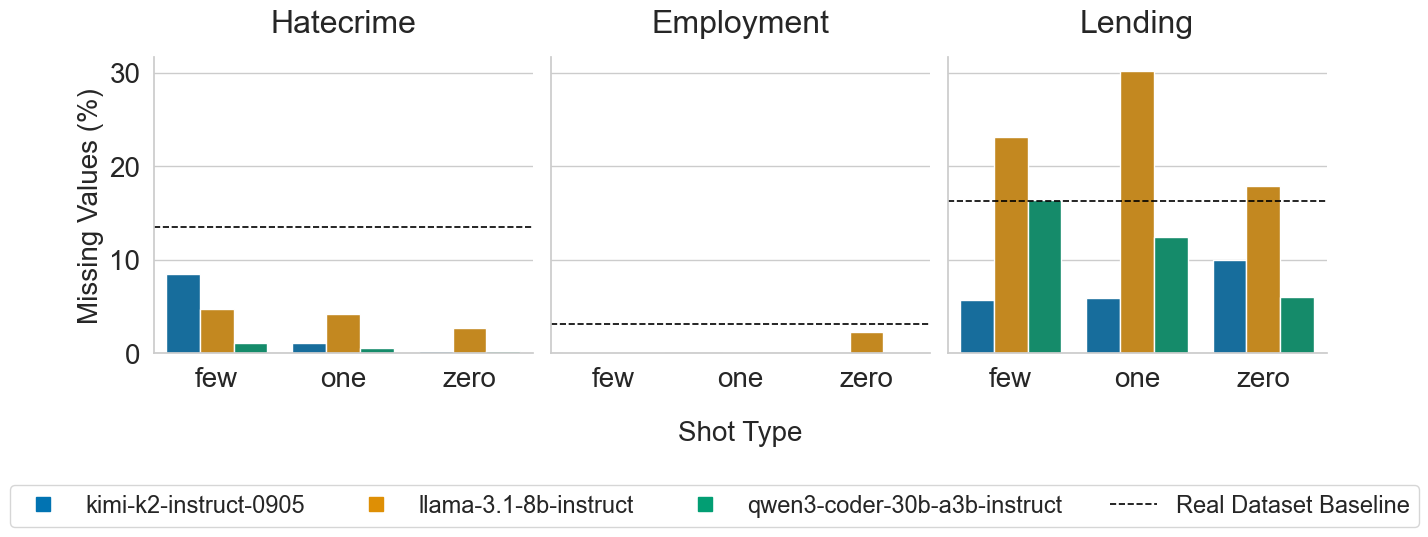

In [ ]:
missing_metric = "generated_overall_missing_pct"
if missing_metric not in missing_summary.columns:
    missing_metric = "generated_overall_missing_pct_mean"

g_miss = sns.catplot(
    data=missing_summary,
    kind="bar",
    x="shot",
    y=missing_metric,
    hue="model",
    col="domain",
    hue_order=models,
    col_order=domains,
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.05,
    sharey=True,
    legend=False,
)

g_miss.fig.set_size_inches(4 * 1.05 * len(domains), 4)

g_miss.set_titles("{col_name}")

for i, (ax, domain) in enumerate(zip(g_miss.axes.flat, domains)):
    baseline = real_metrics.loc[real_metrics["domain"] == domain, "overall_missing_pct"]
    if not baseline.empty:
        ax.axhline(
            y=baseline.iloc[0],
            color="black",
            linestyle="--",
            linewidth=1.2,
        )
    
    ax.set_title(
        domain.capitalize(),
        fontsize=FONT_CONFIG['axes_title_size'],
        pad=FONT_CONFIG['axes_title_pad'],
    )
    if i == len(domains) // 2:
        ax.set_xlabel("Shot Type", fontsize=FONT_CONFIG['axes_label_size'], labelpad=20)
    else:
        ax.set_xlabel("", fontsize=FONT_CONFIG['axes_label_size'])
    ax.set_ylabel("Missing Values (%)", fontsize=FONT_CONFIG['axes_label_size'])
    ax.tick_params(axis='both', labelsize=FONT_CONFIG['tick_size'])

handles_miss = [
    Line2D([0], [0], marker="s", linestyle="none", markersize=10, color=MODEL_PALETTE[model], label=model)
    for model in models
]

baseline_handle = Line2D(
    [0], [0], color="black", linestyle="--", linewidth=1.2, label="Real Dataset Baseline"
)
handles_miss.append(baseline_handle)
labels_miss = list(models) + ["Real Dataset Baseline"]

g_miss.fig.legend(
    handles_miss,
    labels_miss,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=max(1, len(models) + 1),
    fontsize=FONT_CONFIG['legend_size'],
    frameon=True,
)

plt.savefig(FIGURES_DIR / "missing_values_by_domain_shot_llm.png", bbox_inches='tight')
plt.show()

## Data Type Consistency


In [11]:

quality_summary = (
    merged_runs
    .groupby(["domain", "model", "shot"], as_index=False)
    .agg({
        "generated_type_correctness_pct": "mean",
        "generated_overall_missing_pct": "mean",
        "real_overall_missing_pct": "mean",
        "generated_duplicate_rows_pct": "mean",
        "real_duplicate_rows_pct": "mean",
        "row_constraints_mean_violations_pct": "mean",
        "row_constraints_max_violations_pct": "max",
        "numeric_outlier_pct_mean": "mean",
        "categorical_unexpected_value_pct_mean": "mean",
        "date_invalid_values_pct_mean": "mean",
        "numeric_avg_ks_real_vs_generated": "mean",
        "categorical_avg_js_divergence_real_vs_generated": "mean",
        "text_avg_length_abs_diff_mean": "mean",
        "text_empty_pct_generated_mean": "mean",
    })
)

quality_summary["duplicate_pct_delta"] = (
    quality_summary["generated_duplicate_rows_pct"] - quality_summary["real_duplicate_rows_pct"]
)
quality_summary["missing_pct_delta"] = (
    quality_summary["generated_overall_missing_pct"] - quality_summary["real_overall_missing_pct"]
)

quality_summary

,domain,model,shot,generated_type_correctness_pct,generated_overall_missing_pct,real_overall_missing_pct,generated_duplicate_rows_pct,real_duplicate_rows_pct,row_constraints_mean_violations_pct,row_constraints_max_violations_pct,numeric_outlier_pct_mean,categorical_unexpected_value_pct_mean,date_invalid_values_pct_mean,numeric_avg_ks_real_vs_generated,categorical_avg_js_divergence_real_vs_generated,text_avg_length_abs_diff_mean,text_empty_pct_generated_mean,duplicate_pct_delta,missing_pct_delta
0,employment,kimi-k2-instruct-0905,few,96.296296,0.059775,3.137883,0.000000,0.000000,0.123047,0.199402,0.802428,58.923732,0.000000,0.401206,0.560440,2.172045,0.0,0.000000,-3.078108
1,employment,kimi-k2-instruct-0905,one,72.222222,0.000000,3.137883,0.000000,0.000000,0.033636,0.100908,1.201889,45.529117,0.033670,0.418178,0.477973,2.173386,0.0,0.000000,-3.137883
2,employment,kimi-k2-instruct-0905,zero,74.074074,0.000000,3.137883,0.000000,0.000000,0.032808,0.098425,1.189072,96.651507,0.032841,0.303974,0.790466,5.417835,0.0,0.000000,-3.137883
3,employment,llama-3.1-8b-instruct,few,46.296296,0.148464,3.137883,1.736505,0.000000,76.370696,90.261780,2.229155,37.875633,10.387972,0.365793,0.436824,1.236684,0.0,1.736505,-2.989419
4,employment,llama-3.1-8b-instruct,one,48.148148,0.110669,3.137883,4.726465,0.000000,88.979451,93.247588,6.873127,60.976393,3.487868,0.541231,0.635456,1.106894,0.0,4.726465,-3.027214
5,employment,llama-3.1-8b-instruct,zero,44.444444,2.286571,3.137883,0.417753,0.000000,99.241293,100.000000,10.470268,62.796834,8.161499,0.374917,0.731797,2.934957,0.0,0.417753,-0.851312
6,employment,qwen3-coder-30b-a3b-instruct,few,70.370370,0.094933,3.137883,0.476485,0.000000,1.124915,6.595538,1.713511,36.643488,0.064173,0.379887,0.426090,1.887862,0.0,0.476485,-3.042950
7,employment,qwen3-coder-30b-a3b-instruct,one,92.592593,0.037698,3.137883,0.647072,0.000000,48.011232,61.862745,3.673858,43.595744,0.064520,0.515116,0.505046,1.935327,0.0,0.647072,-3.100185
8,employment,qwen3-coder-30b-a3b-instruct,zero,94.444444,0.070323,3.137883,0.000000,0.000000,99.803383,100.000000,1.819037,91.153921,0.000000,0.508344,0.743409,5.307862,0.0,0.000000,-3.067559
9,hatecrime,kimi-k2-instruct-0905,few,100.000000,8.458319,13.516142,0.463065,1.536297,2.567033,9.760956,0.745631,5.118777,0.000000,0.375528,0.297344,0.000000,0.0,-1.073232,-5.057822


In [12]:
type_summary = (
    quality_summary
    .loc[:, ["domain", "model", "shot", "generated_type_correctness_pct"]]
    .sort_values("generated_type_correctness_pct", ascending=False)
    .reset_index(drop=True)
)

type_summary

,domain,model,shot,generated_type_correctness_pct
0,hatecrime,kimi-k2-instruct-0905,few,100.000000
1,hatecrime,kimi-k2-instruct-0905,zero,98.333333
2,employment,kimi-k2-instruct-0905,few,96.296296
3,hatecrime,qwen3-coder-30b-a3b-instruct,zero,95.000000
4,employment,qwen3-coder-30b-a3b-instruct,zero,94.444444
5,employment,qwen3-coder-30b-a3b-instruct,one,92.592593
6,hatecrime,qwen3-coder-30b-a3b-instruct,few,90.000000
7,hatecrime,qwen3-coder-30b-a3b-instruct,one,88.333333
8,hatecrime,llama-3.1-8b-instruct,one,75.000000
9,employment,kimi-k2-instruct-0905,zero,74.074074


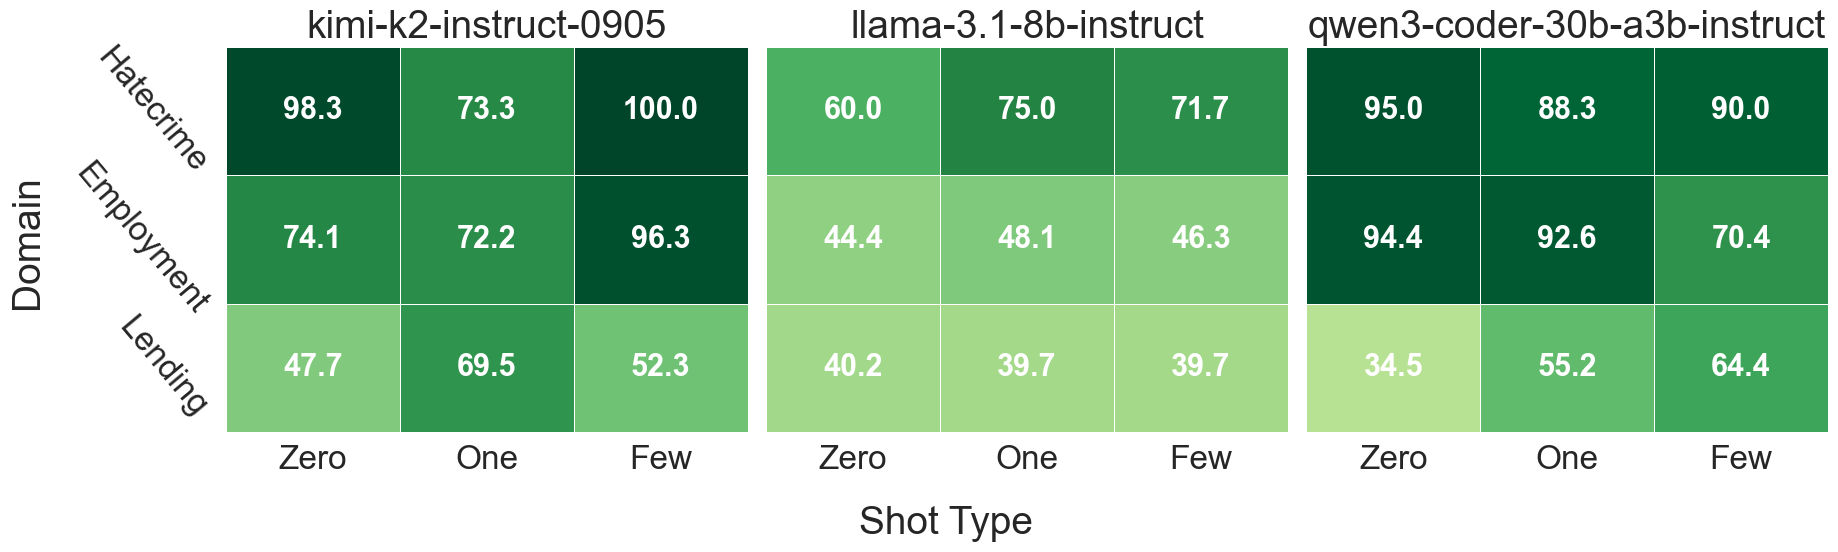

In [82]:
df = type_summary.copy()
df["domain"] = pd.Categorical(df["domain"], DOMAIN_ORDER)
df["shot"] = pd.Categorical(df["shot"], SHOT_ORDER)
df["model"] = pd.Categorical(df["model"], MODEL_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, (ax, model) in enumerate(zip(axes, MODEL_ORDER)):

    pivot = df[df["model"] == model].pivot(
        index="domain",
        columns="shot",
        values="generated_type_correctness_pct"
    )

    sns.heatmap(
        pivot,
        cmap="YlGn",
        annot=True,
        fmt=".1f",
        annot_kws={"size": 22, "weight": "bold", "color": "white"},
        cbar=False,
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title(model, fontsize=28)
    ax.set_xlabel("")
    ax.set_ylabel("")


    ax.set_xticklabels(
        [label.get_text().title() for label in ax.get_xticklabels()],
        fontsize=24,
        rotation=0
    )
    ax.set_yticklabels(
        [label.get_text().title() for label in ax.get_yticklabels()],
        fontsize=24,
        rotation=-50
    )

    if idx != 0:
        ax.set_yticklabels([])

fig.supxlabel("Shot Type", fontsize=28, y=-0.1)
fig.supylabel("Domain", fontsize=28, x=-0.02)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, left=0.10)
plt.savefig(FIGURES_DIR / "type_correctness_heatmaps.png", bbox_inches="tight", dpi=300)
plt.show()

## Example of inspection of data type check

In [14]:
inspect_type_correctness_runs("kimi-k2-instruct-0905", "hatecrime", "one")


Type correctness by run for kimi-k2-instruct-0905 | hatecrime | one
run_id                   run_name  generated_type_correctness_pct
  run1 kimi-k2-instruct-0905-run1                           100.0
  run2 kimi-k2-instruct-0905-run2                            60.0
  run3 kimi-k2-instruct-0905-run3                            60.0

Average correctness across 3 run(s): 73.33%

Per-run column types vs real dataset

Run run1 (kimi-k2-instruct-0905-run1)
                  Column Real type Observed type Status
    adult_offender_count   numeric       numeric     OK
      adult_victim_count   numeric       numeric     OK
        agency_type_name    object        object     OK
               bias_desc    object        object     OK
               data_year   numeric       numeric     OK
           incident_date    object        object     OK
 juvenile_offender_count   numeric       numeric     OK
   juvenile_victim_count   numeric       numeric     OK
           location_name    object       

,run_id,run_name,generated_type_correctness_pct
0,run1,kimi-k2-instruct-0905-run1,100.0
1,run2,kimi-k2-instruct-0905-run2,60.0
2,run3,kimi-k2-instruct-0905-run3,60.0


## Logical Constraints checks


In [15]:
constraint_summary = (
    quality_summary
    .loc[
        :,
        [
            "domain",
            "model",
            "shot",
            "row_constraints_mean_violations_pct",
            "row_constraints_max_violations_pct",
            "categorical_unexpected_value_pct_mean",
            "date_invalid_values_pct_mean",
        ],
    ]
    .sort_values("row_constraints_mean_violations_pct", ascending=False)
    .reset_index(drop=True)
)

constraint_summary

,domain,model,shot,row_constraints_mean_violations_pct,row_constraints_max_violations_pct,categorical_unexpected_value_pct_mean,date_invalid_values_pct_mean
0,employment,qwen3-coder-30b-a3b-instruct,zero,99.803383,100.000000,91.153921,0.000000
1,employment,llama-3.1-8b-instruct,zero,99.241293,100.000000,62.796834,8.161499
2,employment,llama-3.1-8b-instruct,one,88.979451,93.247588,60.976393,3.487868
3,lending,qwen3-coder-30b-a3b-instruct,one,85.373141,93.465347,42.078635,NaN
4,employment,llama-3.1-8b-instruct,few,76.370696,90.261780,37.875633,10.387972
5,lending,llama-3.1-8b-instruct,few,71.072617,83.849130,37.364800,NaN
6,lending,llama-3.1-8b-instruct,one,70.307906,80.661841,34.244660,NaN
7,employment,qwen3-coder-30b-a3b-instruct,one,48.011232,61.862745,43.595744,0.064520
8,lending,kimi-k2-instruct-0905,one,34.216776,48.367953,78.755865,NaN
9,lending,qwen3-coder-30b-a3b-instruct,few,31.697643,33.545310,33.567642,NaN


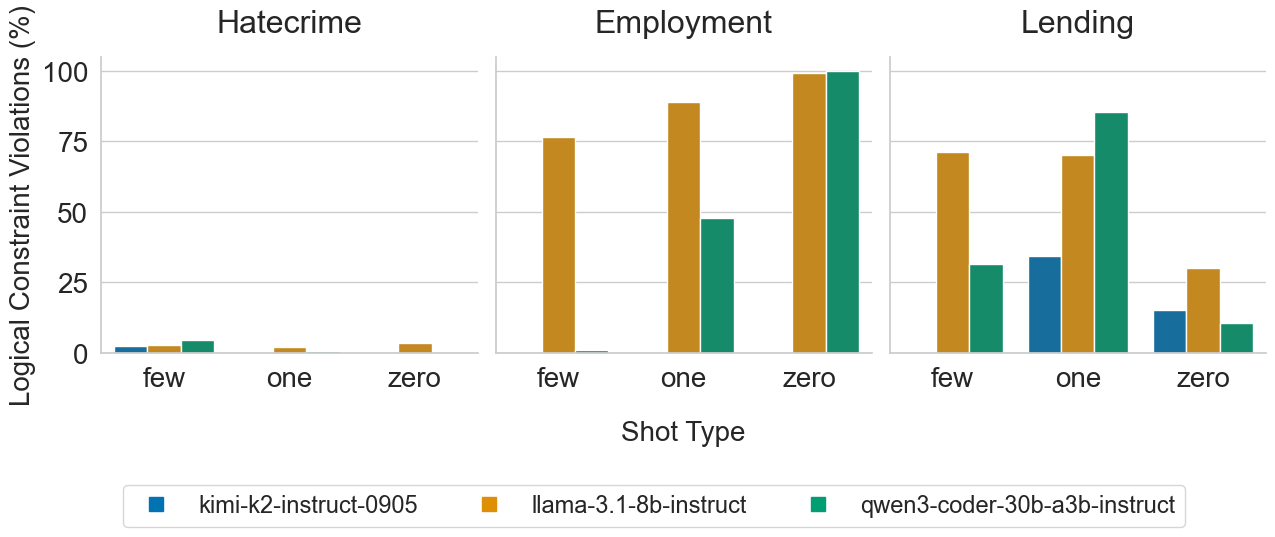

In [ ]:
g = sns.catplot(
    data=quality_summary,
    kind="bar",
    x="shot",
    y="row_constraints_mean_violations_pct",
    hue="model",
    col="domain",
    hue_order=models,
    col_order=domains,
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.05,
    sharey=True,
    legend=False,
)

g.fig.set_size_inches(4 * 1.05 * len(domains), 4)

g.set_titles("{col_name}")

for i, (ax, domain) in enumerate(zip(g.axes.flat, domains)):
    ax.set_title(
        domain.capitalize(),
        fontsize=FONT_CONFIG['axes_title_size'],
        pad=FONT_CONFIG['axes_title_pad'],
    )

    if i == len(domains) // 2:
        ax.set_xlabel("Shot Type", fontsize=FONT_CONFIG['axes_label_size'], labelpad=20)
    else:
        ax.set_xlabel("", fontsize=FONT_CONFIG['axes_label_size'])
    ax.set_ylabel("Logical Constraint Violations (%)", fontsize=FONT_CONFIG['axes_label_size'])
    ax.tick_params(axis='both', labelsize=FONT_CONFIG['tick_size'])

handles = [
    Line2D([0], [0], marker="s", linestyle="none", markersize=10, color=MODEL_PALETTE[model], label=model)
    for model in models
]

g.fig.legend(
    handles,
    models,
    fontsize=FONT_CONFIG['legend_size'],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=min(len(models), 3),
    frameon=True,
)

plt.savefig(FIGURES_DIR / "logical_constraints_by_domain_shot_llm.png", bbox_inches='tight')
plt.show()

## Distribution Alignment vs. Real Data
The average Kolmogorov–Smirnov (numeric) and Jensen–Shannon (categorical) statistics quantify how close generated distributions are to the real ones (0 means perfect overlap). Lower values indicate closer alignment with real data. Points closer to the bottom-left corner demonstrate better distributional fidelity.


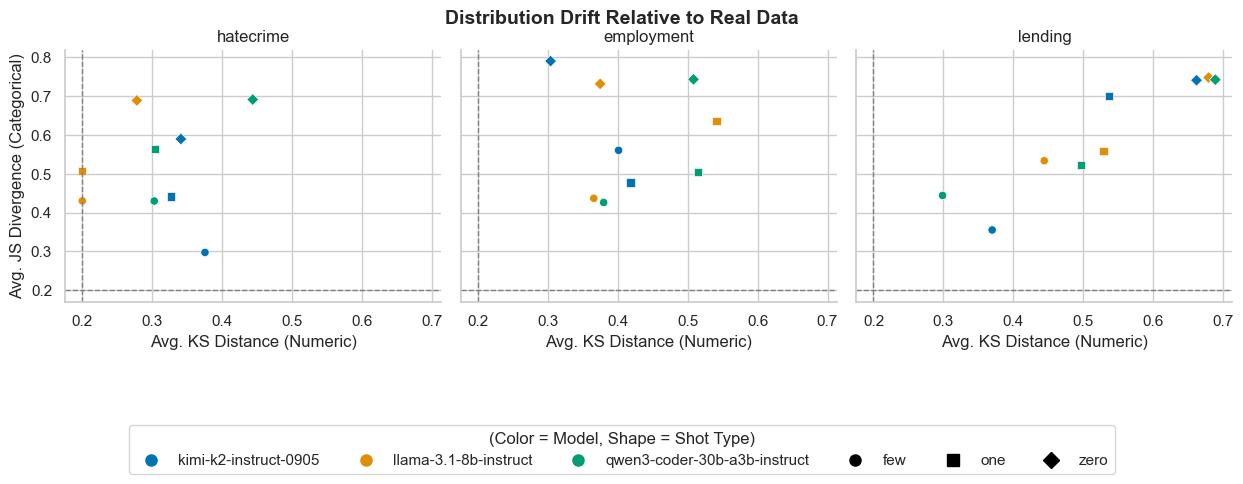

In [17]:
models = ordered_levels(quality_summary["model"].unique(), MODEL_ORDER)
domains = ordered_levels(quality_summary["domain"].unique(), DOMAIN_ORDER)
shots = sorted(quality_summary["shot"].unique())

marker_cycle = ["o", "s", "D", "^", "v", "P", "X", "*"]
shot_markers = {s: marker_cycle[i % len(marker_cycle)] for i, s in enumerate(shots)}

g = sns.relplot(
    data=quality_summary,
    kind="scatter",
    x="numeric_avg_ks_real_vs_generated",
    y="categorical_avg_js_divergence_real_vs_generated",
    hue="model",
    palette=MODEL_PALETTE,
    hue_order=models,
    style="shot",
    style_order=shots,
    markers=shot_markers,
    col="domain",
    col_order=domains,
    height=4,
    aspect=1.05,
    legend=False,
)

g.set_axis_labels("Avg. KS Distance (Numeric)", "Avg. JS Divergence (Categorical)")
g.set_titles("{col_name}")

for ax_row in g.axes:
    for ax in ax_row:
        ax.axvline(0.2, color="grey", linestyle="--", linewidth=1)
        ax.axhline(0.2, color="grey", linestyle="--", linewidth=1)

g.fig.subplots_adjust(top=0.88, bottom=0.25)
g.fig.suptitle("Distribution Drift Relative to Real Data", fontsize=14, weight="bold")

combined_handles = []

for m in models:
    combined_handles.append(
        Line2D([0], [0], marker="o", color=MODEL_PALETTE[m], linestyle="", markersize=8, label=m)
    )

for s in shots:
    combined_handles.append(
        Line2D([0], [0], marker=shot_markers[s], color="black", linestyle="", markersize=8, label=f"{s}")
    )

g.fig.legend(
    handles=combined_handles,
    title="(Color = Model, Shape = Shot Type)",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=6,
    frameon=True,
)

plt.show()

In [18]:
drift_summary = (
    quality_summary
    .loc[
        :,
        [
            "domain",
            "model",
            "shot",
            "numeric_avg_ks_real_vs_generated",
            "categorical_avg_js_divergence_real_vs_generated",
        ],
    ]
    .sort_values(
        ["numeric_avg_ks_real_vs_generated", "categorical_avg_js_divergence_real_vs_generated"],
        ascending=False,
    )
    .reset_index(drop=True)
)

drift_summary

,domain,model,shot,numeric_avg_ks_real_vs_generated,categorical_avg_js_divergence_real_vs_generated
0,lending,qwen3-coder-30b-a3b-instruct,zero,0.688754,0.742585
1,lending,llama-3.1-8b-instruct,zero,0.679225,0.748075
2,lending,kimi-k2-instruct-0905,zero,0.661893,0.741092
3,employment,llama-3.1-8b-instruct,one,0.541231,0.635456
4,lending,kimi-k2-instruct-0905,one,0.537216,0.700302
5,lending,llama-3.1-8b-instruct,one,0.528988,0.559383
6,employment,qwen3-coder-30b-a3b-instruct,one,0.515116,0.505046
7,employment,qwen3-coder-30b-a3b-instruct,zero,0.508344,0.743409
8,lending,qwen3-coder-30b-a3b-instruct,one,0.496656,0.522752
9,lending,llama-3.1-8b-instruct,few,0.444169,0.533626


In [19]:
top_duplicates = (
    merged_runs
    .loc[:, [
        "domain", "model", "shot", "run_name",
        "generated_duplicate_rows_pct", "real_duplicate_rows_pct", "duplicate_pct_delta"
    ]]
    .sort_values("duplicate_pct_delta", ascending=False)
    .reset_index(drop=True)
)

top_duplicates

,domain,model,shot,run_name,generated_duplicate_rows_pct,real_duplicate_rows_pct,duplicate_pct_delta
0,lending,qwen3-coder-30b-a3b-instruct,few,qwen3-coder-30b-a3b-instruct-run3,14.308426,0.267783,14.040643
1,lending,llama-3.1-8b-instruct,one,llama-3.1-8b-instruct-run3,14.256410,0.267783,13.988627
2,lending,qwen3-coder-30b-a3b-instruct,few,qwen3-coder-30b-a3b-instruct-run1,11.403509,0.267783,11.135726
3,employment,llama-3.1-8b-instruct,one,llama-3.1-8b-instruct-run3,8.145766,0.000000,8.145766
4,lending,qwen3-coder-30b-a3b-instruct,zero,qwen3-coder-30b-a3b-instruct-run3,6.806283,0.267783,6.538500
...,...,...,...,...,...,...,...
76,hatecrime,llama-3.1-8b-instruct,one,llama-3.1-8b-instruct-run2,0.000000,1.536297,-1.536297
77,hatecrime,llama-3.1-8b-instruct,few,llama-3.1-8b-instruct-run2,0.000000,1.536297,-1.536297
78,hatecrime,qwen3-coder-30b-a3b-instruct,zero,qwen3-coder-30b-a3b-instruct-run3,0.000000,1.536297,-1.536297
79,hatecrime,llama-3.1-8b-instruct,one,llama-3.1-8b-instruct-run1,0.000000,1.536297,-1.536297


In [20]:
real_metrics

,domain,row_count,column_count,overall_missing_pct,duplicate_rows,duplicate_rows_pct,duplicate_rows_primary_key,duplicate_rows_primary_key_pct
0,hatecrime,265834,20,13.516142,4084,1.536297,16901,6.357727
1,employment,11239,18,3.137883,0,0.000000,0,0.000000
2,lending,12229298,58,16.233921,32748,0.267783,5006136,40.935596
